# Safe Highway Overtaking with Model Predictive Control

## 1. Requirement

The ego vehicle should drive on a multi-lane highway and perform safe overtaking when required.

The vehicle should:

1. maintain a desired cruising speed when traffic permits,
2. avoid collisions,
3. detect slower traffic ahead,
4. evaluate future consequences of candidate actions,
5. change lane only when the predicted maneuver remains safe,
6. prefer actions that provide useful forward progress.

Unlike the previous FSM implementation, the decision is not based only on fixed state-transition rules.

Instead, at every decision step the controller evaluates candidate action sequences over a finite prediction horizon.

The general MPC structure is:

$$
\boxed{
\text{observe}
\rightarrow
\text{predict future traffic}
\rightarrow
\text{evaluate candidate actions}
\rightarrow
\text{select best sequence}
\rightarrow
\text{execute first action}
\rightarrow
\text{repeat}
}
$$

## 2. Action Space

We initially retain Highway-env's discrete behavior-level action space:

$$
\mathcal A=
\{
\text{LANE\_LEFT},
\text{IDLE},
\text{LANE\_RIGHT},
\text{FASTER},
\text{SLOWER}
\}.
$$

Therefore, the MPC decision variables are discrete future behavior actions:

$$
U_t=
\{
a_{0|t},
a_{1|t},
\ldots,
a_{N-1|t}
\}.
$$

Only the first optimized action is executed:

$$
a_t=a_{0|t}^*.
$$

The optimization is then repeated from the newly observed traffic state.

## 3. Prediction Model

The MPC requires a predictive model.

For the first behavior-level implementation, we use a simplified short-horizon traffic model.

Each nearby vehicle is represented by:

$$
z_i=
[
\Delta x_i,
\Delta l_i,
\Delta v_{x,i}
],
$$

where:

- $\Delta x_i$ is longitudinal position relative to ego,
- $\Delta l_i$ is relative lane offset,
- $\Delta v_{x,i}$ is relative longitudinal velocity.

For surrounding vehicles, we initially assume constant longitudinal velocity:

$$
v_i(k+1)=v_i(k).
$$

The relative longitudinal position evolves approximately as:

$$
\boxed{
\Delta x_i(k+1)=
\Delta x_i(k)
+
\Delta t\,\Delta v_{x,i}(k).
}
$$

The ego behavior action modifies:

- ego target speed,
- ego lane.

This model is intentionally simpler than Highway-env's internal dynamics.

Its purpose is to provide enough short-horizon prediction for behavior planning.

## 4. Environment Setup

The experiment uses `highway-v0` with a discrete behavior-level action space.

The observation uses unnormalized kinematic features for the ego vehicle and nearby traffic:

$$
[
presence,
x,
y,
v_x,
v_y
].
$$

For surrounding vehicles, positions and velocities are represented relative to the ego vehicle.

The action space is:

$$
\mathcal A=
\{
\text{LANE\_LEFT},
\text{IDLE},
\text{LANE\_RIGHT},
\text{FASTER},
\text{SLOWER}
\}.
$$

The policy operates at 1 Hz while the underlying simulation runs at 15 Hz.

In [1]:
# Imports

import gymnasium as gym
import highway_env

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output, Video

In [105]:
# Environment configuration

config = {
    "duration": 200,

    "observation": {
        "type": "Kinematics",
        "vehicles_count": 12,
        "features": [
            "presence",
            "x",
            "y",
            "vx",
            "vy"
        ],
        "absolute": False,
        "normalize": False,
        "see_behind": True
    },

    "action": {
        "type": "DiscreteMetaAction"
    },

    "simulation_frequency": 15,
    "policy_frequency": 1
}

In [106]:
env = gym.make(
    "highway-v0",
    render_mode="rgb_array",
    config=config
)

obs, info = env.reset(seed=42)

print("Observation shape:", obs.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation shape: (12, 5)
Observation space: Box(-inf, inf, (12, 5), float32)
Action space: Discrete(5)


In [107]:
def show_env(env, figsize=(12, 4)):
    frame = env.render()

    plt.figure(figsize=figsize)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

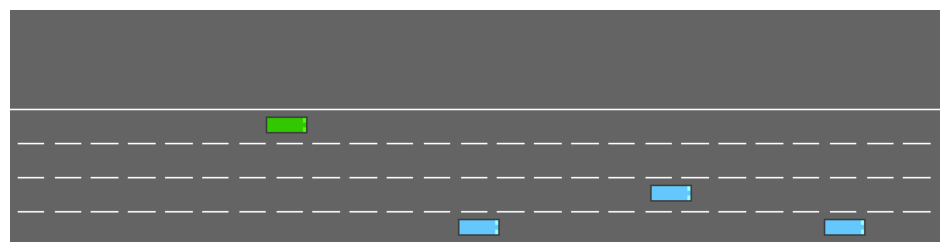

In [108]:
show_env(env)

## 5. MPC Prediction State

The raw Highway-env observation contains nearby vehicles as:

$$
[
presence,
\Delta x,
\Delta y,
\Delta v_x,
\Delta v_y
].
$$

For behavior-level MPC, we simplify this representation.

The ego state is represented by:

$$
x_{\text{ego}}=
[
l_{\text{ego}},
v_{\text{ego}}
],
$$

where:

- $l_{\text{ego}}$ is the current lane index,
- $v_{\text{ego}}$ is the ego longitudinal speed.

Each surrounding vehicle is represented by:

$$
x_i=
[
\Delta x_i,
l_i,
v_i
].
$$

Thus, the prediction model keeps only the quantities required for longitudinal progress, lane occupancy, and collision reasoning.

In [6]:
def relative_lane_offset(
    dy,
    lane_width=4.0,
    same_lane_tol=1.5
):
    if abs(dy) < same_lane_tol:
        return 0

    magnitude = int(
        np.ceil(abs(dy) / lane_width)
    )

    return magnitude if dy > 0 else -magnitude

In [7]:
def build_mpc_state(obs, env):

    ego = env.unwrapped.vehicle

    ego_lane = int(
        ego.lane_index[2]
    )

    ego_speed = float(
        ego.speed
    )

    traffic = []

    for i, row in enumerate(
        obs[1:],
        start=1
    ):

        presence, dx, dy, dvx, dvy = row

        if presence == 0:
            continue

        lane_offset = relative_lane_offset(
            float(dy)
        )

        absolute_lane = (
            ego_lane + lane_offset
        )

        # Relative velocity:
        # dvx = v_other - v_ego
        other_speed = (
            ego_speed + float(dvx)
        )

        traffic.append({
            "id": i,
            "dx": float(dx),
            "dy": float(dy),
            "lane": absolute_lane,
            "speed": other_speed
        })

    return {
        "ego_lane": ego_lane,
        "ego_speed": ego_speed,
        "traffic": traffic
    }

In [8]:
mpc_state = build_mpc_state(
    obs,
    env
)

mpc_state

{'ego_lane': 0,
 'ego_speed': 25.0,
 'traffic': [{'id': 1,
   'dx': 22.429563522338867,
   'dy': 12.0,
   'lane': 3,
   'speed': 23.575793743133545},
  {'id': 2,
   'dx': 45.054420471191406,
   'dy': 8.0,
   'lane': 2,
   'speed': 23.283419132232666},
  {'id': 3,
   'dx': 65.35106658935547,
   'dy': 12.0,
   'lane': 3,
   'speed': 22.351157903671265},
  {'id': 4,
   'dx': 86.62020874023438,
   'dy': 12.0,
   'lane': 3,
   'speed': 23.468284845352173},
  {'id': 5,
   'dx': 105.81072235107422,
   'dy': 8.0,
   'lane': 2,
   'speed': 22.6637544631958},
  {'id': 6,
   'dx': 126.58316040039062,
   'dy': 4.0,
   'lane': 1,
   'speed': 23.27426326274872},
  {'id': 7,
   'dx': 149.4286651611328,
   'dy': 8.0,
   'lane': 2,
   'speed': 23.67936336994171}]}

In [9]:
for vehicle in mpc_state["traffic"]:
    print(vehicle["dy"])

12.0
8.0
12.0
12.0
8.0
4.0
8.0


## 6. Simplified Discrete Action Model

The behavior-level actions are approximated as follows:

$$
\text{LANE\_LEFT}
:
l_{k+1}=l_k-1
$$

$$
\text{LANE\_RIGHT}
:
l_{k+1}=l_k+1
$$

$$
\text{FASTER}
:
v_{k+1}=v_k+\Delta v
$$

$$
\text{SLOWER}
:
v_{k+1}=v_k-\Delta v
$$

$$
\text{IDLE}
:
(l_{k+1},v_{k+1})=
(l_k,v_k).
$$

This is a behavior-level prediction model rather than a low-level vehicle dynamics model.

In [11]:
ACTION_LANE_LEFT = 0
ACTION_IDLE = 1
ACTION_LANE_RIGHT = 2
ACTION_FASTER = 3
ACTION_SLOWER = 4

ACTION_NAMES = {
    ACTION_LANE_LEFT: "LANE_LEFT",
    ACTION_IDLE: "IDLE",
    ACTION_LANE_RIGHT: "LANE_RIGHT",
    ACTION_FASTER: "FASTER",
    ACTION_SLOWER: "SLOWER",
}

In [138]:
DT = 1.0

SPEED_STEP = 5.0

MIN_SPEED = 0.0
MAX_SPEED = 30.0

LANES_COUNT = 4

In [88]:
def predict_step(state, action):

    ego_lane = state["ego_lane"]
    ego_speed = state["ego_speed"]

    # --------------------------------
    # Apply discrete ego action
    # --------------------------------

    if action == ACTION_LANE_LEFT:
        ego_lane = max(
            0,
            ego_lane - 1
        )

    elif action == ACTION_LANE_RIGHT:
        ego_lane = min(
            LANES_COUNT - 1,
            ego_lane + 1
        )

    elif action == ACTION_FASTER:
        ego_speed = min(
            MAX_SPEED,
            ego_speed + SPEED_STEP
        )

    elif action == ACTION_SLOWER:
        ego_speed = max(
            MIN_SPEED,
            ego_speed - SPEED_STEP
        )

    # --------------------------------
    # Predict traffic relative motion
    # --------------------------------

    predicted_traffic = []

    for vehicle in state["traffic"]:

        relative_speed = (
            vehicle["speed"]
            - ego_speed
        )

        dx_next = (
            vehicle["dx"]
            + DT * relative_speed
        )

        predicted_traffic.append({
            "id": vehicle["id"],
            "dx": dx_next,
            "dy": vehicle["dy"],
            "lane": vehicle["lane"],
            "speed": vehicle["speed"]
        })

    return {
        "ego_lane": ego_lane,
        "ego_speed": ego_speed,
        "traffic": predicted_traffic
    }

In [14]:
def rollout_sequence(
    initial_state,
    action_sequence
):

    states = [initial_state]

    state = initial_state

    for action in action_sequence:

        state = predict_step(
            state,
            action
        )

        states.append(state)

    return states

In [15]:
test_sequence = [
    ACTION_FASTER,
    ACTION_LANE_RIGHT,
    ACTION_IDLE,
    ACTION_IDLE
]

predicted_states = rollout_sequence(
    mpc_state,
    test_sequence
)

In [16]:
for k, state in enumerate(predicted_states):

    print(
        f"k={k} | "
        f"lane={state['ego_lane']} | "
        f"speed={state['ego_speed']:.1f}"
    )

k=0 | lane=0 | speed=25.0
k=1 | lane=0 | speed=30.0
k=2 | lane=1 | speed=30.0
k=3 | lane=1 | speed=30.0
k=4 | lane=1 | speed=30.0


## 7. MPC Objective

For every candidate action sequence:

$$
U_t=
\{
a_{0|t},
a_{1|t},
\ldots,
a_{N-1|t}
\},
$$

the prediction model generates future ego and traffic states.

The MPC objective should encourage:

- forward progress,
- maintaining a desired cruising speed,
- sufficient distance from nearby vehicles,
- avoiding unnecessary lane changes.

Safety is given the highest priority.

Conceptually:

$$
\boxed{
J=
J_{\text{speed}}
+
J_{\text{safety}}
+
J_{\text{lane change}}
}
$$

The optimal sequence is:

$$
U_t^*=
\arg\min_U J(U).
$$

Only the first action:

$$
a_{0|t}^*
$$

is executed.

In [116]:
PREDICTION_HORIZON = 4

DESIRED_SPEED = 25.0

W_SPEED = 1.0
W_LANE_CHANGE = 5.0

MIN_SAFE_GAP = 15.0

COLLISION_PENALTY = 1000.0
CLOSE_GAP_PENALTY = 100.0

W_PROXIMITY = 20.0
SAFE_DISTANCE = 30.0

MIN_LANE_CHANGE_FRONT_GAP = 20.0
MIN_LANE_CHANGE_REAR_GAP = 20.0

MIN_LONGITUDINAL_GAP = 10.0

In [18]:
def vehicles_in_ego_lane(state):
    ego_lane = state["ego_lane"]

    return [
        vehicle
        for vehicle in state["traffic"]
        if vehicle["lane"] == ego_lane
    ]

In [19]:
def state_cost(state):

    cost = 0.0

    ego_speed = state["ego_speed"]

    # -------------------------
    # Speed objective
    # -------------------------

    speed_error = (
        ego_speed - DESIRED_SPEED
    )

    cost += (
        W_SPEED * speed_error**2
    )

    # -------------------------
    # Safety
    # -------------------------

    same_lane_vehicles = (
        vehicles_in_ego_lane(state)
    )

    for vehicle in same_lane_vehicles:

        dx = vehicle["dx"]
    
        # Only vehicle ahead for this term
        if dx > 0:
    
            # Collision / extremely unsafe
            if dx < 5.0:
                cost += COLLISION_PENALTY
    
            # Hard unsafe zone
            elif dx < MIN_SAFE_GAP:
                cost += CLOSE_GAP_PENALTY
    
            # Soft proximity cost
            elif dx < SAFE_DISTANCE:
                cost += (
                    W_PROXIMITY
                    * (SAFE_DISTANCE - dx) ** 2
                    / SAFE_DISTANCE**2
                )

    return cost

In [117]:
def longitudinal_state_is_safe(state):

    ego_lane = state["ego_lane"]

    for vehicle in state["traffic"]:

        if vehicle["lane"] != ego_lane:
            continue

        dx = vehicle["dx"]

        # Only vehicles ahead
        if dx > 0 and dx < MIN_LONGITUDINAL_GAP:
            return False

    return True

In [146]:
def longitudinal_transition_is_safe(
    state,
    next_state,
    min_gap=10.0
):

    ego_lane = state["ego_lane"]
    next_ego_lane = next_state["ego_lane"]

    # Only use this longitudinal check when
    # ego remains in the same lane
    if ego_lane != next_ego_lane:
        return True

    current_by_id = {
        v["id"]: v
        for v in state["traffic"]
    }

    next_by_id = {
        v["id"]: v
        for v in next_state["traffic"]
    }

    for vehicle_id, current_vehicle in current_by_id.items():

        if current_vehicle["lane"] != ego_lane:
            continue

        if vehicle_id not in next_by_id:
            continue

        next_vehicle = next_by_id[vehicle_id]

        dx_now = current_vehicle["dx"]
        dx_next = next_vehicle["dx"]

        # Already too close
        if 0 < dx_now < min_gap:
            return False

        # Relative position crossed through zero:
        # ego passed through the other vehicle
        if dx_now > 0 and dx_next <= 0:
            return False

        # Predicted next gap too small
        if 0 < dx_next < min_gap:
            return False

    return True

In [91]:
LANE_WIDTH = 4.0
LANE_CORRIDOR_TOL = 2.0

def lane_change_is_safe(state, target_lane):

    
    ego_lane = state["ego_lane"]

    lane_offset = target_lane - ego_lane

    target_dy = lane_offset * LANE_WIDTH
    for vehicle in state["traffic"]:
        dx = vehicle["dx"]
        dy = vehicle["dy"]

        # Vehicle lies near the target-lane corridor
        in_target_corridor = (
            abs(dy - target_dy)
            < LANE_CORRIDOR_TOL
        )

        if not in_target_corridor:
            continue

        if dx >= 0:
            if dx < MIN_LANE_CHANGE_FRONT_GAP:
                return False
        else:
            if abs(dx) < MIN_LANE_CHANGE_REAR_GAP:
                return False

    return True

In [72]:
INVALID_ACTION_PENALTY = 1000.0

def action_is_valid(state, action):

    lane = state["ego_lane"]

    # Road boundary
    if action == ACTION_LANE_LEFT:
        if lane == 0:
            return False

        target_lane = lane - 1

        if not lane_change_is_safe(
            state,
            target_lane
        ):
            return False

    if action == ACTION_LANE_RIGHT:
        if lane == LANES_COUNT - 1:
            return False

        target_lane = lane + 1

        if not lane_change_is_safe(
            state,
            target_lane
        ):
            return False

    return True

In [147]:
def sequence_cost(initial_state, action_sequence):

    state = initial_state
    cost = 0.0

    for action in action_sequence:

        if not action_is_valid(state, action):
            return np.inf

        if action in (
            ACTION_LANE_LEFT,
            ACTION_LANE_RIGHT
        ):
            cost += W_LANE_CHANGE

        next_state = predict_step(
            state,
            action
        )

        # Check safety across the transition
        if not longitudinal_transition_is_safe(
            state,
            next_state
        ):
            return np.inf

        cost += state_cost(next_state)

        state = next_state

    return cost

print("done")

done


In [56]:
ACTION_LANE_LEFT = 0
ACTION_IDLE = 1
ACTION_LANE_RIGHT = 2
ACTION_FASTER = 3
ACTION_SLOWER = 4

ACTION_NAMES = {
    ACTION_LANE_LEFT: "LANE_LEFT",
    ACTION_IDLE: "IDLE",
    ACTION_LANE_RIGHT: "LANE_RIGHT",
    ACTION_FASTER: "FASTER",
    ACTION_SLOWER: "SLOWER",
}

In [44]:
DT = 1.0

SPEED_STEP = 5.0

MIN_SPEED = 20.0
MAX_SPEED = 30.0

LANES_COUNT = 4

In [82]:
def predict_step(state, action):

    ego_lane = state["ego_lane"]
    ego_speed = state["ego_speed"]

    # --------------------------------
    # Apply discrete ego action
    # --------------------------------

    if action == ACTION_LANE_LEFT:
        ego_lane = max(
            0,
            ego_lane - 1
        )

    elif action == ACTION_LANE_RIGHT:
        ego_lane = min(
            LANES_COUNT - 1,
            ego_lane + 1
        )

    elif action == ACTION_FASTER:
        ego_speed = min(
            MAX_SPEED,
            ego_speed + SPEED_STEP
        )

    elif action == ACTION_SLOWER:
        ego_speed = max(
            MIN_SPEED,
            ego_speed - SPEED_STEP
        )

    # --------------------------------
    # Predict traffic relative motion
    # --------------------------------

    predicted_traffic = []

    for vehicle in state["traffic"]:

        relative_speed = (
            vehicle["speed"]
            - ego_speed
        )

        dx_next = (
            vehicle["dx"]
            + DT * relative_speed
        )

        predicted_traffic.append({
            "id": vehicle["id"],
            "dx": dx_next,
            "lane": vehicle["lane"],
            "speed": vehicle["speed"]
        })

    return {
        "ego_lane": ego_lane,
        "ego_speed": ego_speed,
        "traffic": predicted_traffic
    }

In [82]:
sequence_1 = [
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE
]

sequence_2 = [
    ACTION_SLOWER,
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE
]

sequence_3 = [
    ACTION_LANE_RIGHT,
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE
]

for sequence in [
    sequence_1,
    sequence_2,
    sequence_3
]:

    print(
        [ACTION_NAMES[a] for a in sequence],
        "-> cost:",
        sequence_cost(
            mpc_state,
            sequence
        )
    )

['IDLE', 'IDLE', 'IDLE', 'IDLE'] -> cost: 0.0
['SLOWER', 'IDLE', 'IDLE', 'IDLE'] -> cost: 100.0
{'id': 1, 'dx': 22.429563522338867, 'dy': 12.0, 'lane': 3, 'speed': 23.575793743133545}
{'id': 2, 'dx': 45.054420471191406, 'dy': 8.0, 'lane': 2, 'speed': 23.283419132232666}
{'id': 3, 'dx': 65.35106658935547, 'dy': 12.0, 'lane': 3, 'speed': 22.351157903671265}
{'id': 4, 'dx': 86.62020874023438, 'dy': 12.0, 'lane': 3, 'speed': 23.468284845352173}
{'id': 5, 'dx': 105.81072235107422, 'dy': 8.0, 'lane': 2, 'speed': 22.6637544631958}
{'id': 6, 'dx': 126.58316040039062, 'dy': 4.0, 'lane': 1, 'speed': 23.27426326274872}
{'id': 7, 'dx': 149.4286651611328, 'dy': 8.0, 'lane': 2, 'speed': 23.67936336994171}
['LANE_RIGHT', 'IDLE', 'IDLE', 'IDLE'] -> cost: 5.0


In [82]:
sequence_1 = [
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE
]

sequence_2 = [
    ACTION_SLOWER,
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE
]

sequence_3 = [
    ACTION_LANE_RIGHT,
    ACTION_IDLE,
    ACTION_IDLE,
    ACTION_IDLE
]

for sequence in [
    sequence_1,
    sequence_2,
    sequence_3
]:

    print(
        [ACTION_NAMES[a] for a in sequence],
        "-> cost:",
        sequence_cost(
            mpc_state,
            sequence
        )
    )

['IDLE', 'IDLE', 'IDLE', 'IDLE'] -> cost: 0.0
['SLOWER', 'IDLE', 'IDLE', 'IDLE'] -> cost: 100.0
{'id': 1, 'dx': 22.429563522338867, 'dy': 12.0, 'lane': 3, 'speed': 23.575793743133545}
{'id': 2, 'dx': 45.054420471191406, 'dy': 8.0, 'lane': 2, 'speed': 23.283419132232666}
{'id': 3, 'dx': 65.35106658935547, 'dy': 12.0, 'lane': 3, 'speed': 22.351157903671265}
{'id': 4, 'dx': 86.62020874023438, 'dy': 12.0, 'lane': 3, 'speed': 23.468284845352173}
{'id': 5, 'dx': 105.81072235107422, 'dy': 8.0, 'lane': 2, 'speed': 22.6637544631958}
{'id': 6, 'dx': 126.58316040039062, 'dy': 4.0, 'lane': 1, 'speed': 23.27426326274872}
{'id': 7, 'dx': 149.4286651611328, 'dy': 8.0, 'lane': 2, 'speed': 23.67936336994171}
['LANE_RIGHT', 'IDLE', 'IDLE', 'IDLE'] -> cost: 5.0


## 8. Discrete MPC Search

The behavior-level action space contains five discrete actions.

For a prediction horizon of:

$$
N=4,
$$

the number of possible action sequences is:

$$
5^4=625.
$$

This is small enough to evaluate every candidate sequence.

For each sequence:

1. predict the future traffic states,
2. calculate the sequence cost,
3. retain the lowest-cost sequence.

The MPC controller then executes only the first action of the best sequence.

In [74]:
from itertools import product

ACTION_SET = [
    ACTION_LANE_LEFT,
    ACTION_IDLE,
    ACTION_LANE_RIGHT,
    ACTION_FASTER,
    ACTION_SLOWER
]

In [75]:
def generate_action_sequences(
    horizon=PREDICTION_HORIZON
):
    return list(
        product(
            ACTION_SET,
            repeat=horizon
        )
    )

In [76]:
candidate_sequences = generate_action_sequences()

print(
    "Number of candidate sequences:",
    len(candidate_sequences)
)

Number of candidate sequences: 625


In [77]:
def solve_discrete_mpc(state):

    best_sequence = None
    best_cost = np.inf

    for sequence in candidate_sequences:

        cost = sequence_cost(
            state,
            sequence
        )

        if cost < best_cost:
            best_cost = cost
            best_sequence = sequence

    return best_sequence, best_cost

In [78]:
def rank_action_sequences(state, top_k=10):

    scored = []

    for sequence in candidate_sequences:

        cost = sequence_cost(
            state,
            sequence
        )

        scored.append(
            (cost, sequence)
        )

    scored.sort(
        key=lambda x: x[0]
    )

    return scored[:top_k]

In [89]:
top_sequences = rank_action_sequences(
    mpc_state,
    top_k=10
)

for rank, (cost, sequence) in enumerate(
    top_sequences,
    start=1
):

    names = [
        ACTION_NAMES[a]
        for a in sequence
    ]

    print(
        f"{rank:2d} | "
        f"cost={cost:8.2f} | "
        f"{names}"
    )

{'id': 1, 'dx': 18.156944751739502, 'dy': 12.0, 'lane': 3, 'speed': 23.575793743133545}
{'id': 2, 'dx': 39.904677867889404, 'dy': 8.0, 'lane': 2, 'speed': 23.283419132232666}
{'id': 3, 'dx': 57.40454030036926, 'dy': 12.0, 'lane': 3, 'speed': 22.351157903671265}
{'id': 4, 'dx': 82.0250632762909, 'dy': 12.0, 'lane': 3, 'speed': 23.468284845352173}
{'id': 5, 'dx': 98.80198574066162, 'dy': 8.0, 'lane': 2, 'speed': 22.6637544631958}
{'id': 6, 'dx': 121.40595018863678, 'dy': 4.0, 'lane': 1, 'speed': 23.27426326274872}
{'id': 7, 'dx': 145.46675527095795, 'dy': 8.0, 'lane': 2, 'speed': 23.67936336994171}
{'id': 1, 'dx': 19.581151008605957, 'dy': 12.0, 'lane': 3, 'speed': 23.575793743133545}
{'id': 2, 'dx': 41.62125873565674, 'dy': 8.0, 'lane': 2, 'speed': 23.283419132232666}
{'id': 3, 'dx': 60.053382396698, 'dy': 12.0, 'lane': 3, 'speed': 22.351157903671265}
{'id': 4, 'dx': 83.55677843093872, 'dy': 12.0, 'lane': 3, 'speed': 23.468284845352173}
{'id': 5, 'dx': 101.13823127746582, 'dy': 8.0, 'la

## 9. Receding-Horizon Controller

In [121]:
def mpc_action(obs, env):

    state = build_mpc_state(
        obs,
        env
    )

    best_sequence, best_cost = solve_discrete_mpc(
        state
    )

    if (
        best_sequence is None
        or not np.isfinite(best_cost)
    ):
        return (
            ACTION_SLOWER,
            (ACTION_SLOWER,),
            np.inf
        )

    return (
        best_sequence[0],
        best_sequence,
        best_cost
    )

## 10. Highway-env MPC Rollout

At every policy step:

1. read the current Highway-env observation,
2. build the simplified MPC prediction state,
3. evaluate all candidate action sequences,
4. select the minimum-cost sequence,
5. execute only the first action,
6. observe the new traffic state,
7. solve the optimization again.

Thus:

$$
\boxed{
\text{observe}
\rightarrow
\text{predict}
\rightarrow
\text{optimize}
\rightarrow
\text{execute first action}
\rightarrow
\text{repeat}
}
$$

In [157]:
obs, info = env.reset()

history = []
frames = []
frames.append(env.render())

In [158]:
for t in range(200):

    # Current MPC state
    current_state = build_mpc_state(
        obs,
        env
    )

    # Solve discrete MPC
    action, best_sequence, best_cost = (
        mpc_action(
            obs,
            env
        )
    )

    # ==========================================
    # DEBUG LANE CHANGE BEFORE EXECUTING ACTION
    # ==========================================

    if action in (
        ACTION_LANE_LEFT,
        ACTION_LANE_RIGHT
    ):

        ego_lane = current_state["ego_lane"]

        if action == ACTION_LANE_RIGHT:
            target_lane = ego_lane + 1
        else:
            target_lane = ego_lane - 1

        print(
            f"\n--- LANE CHANGE DEBUG | step={t} ---"
        )

        print("Action:", ACTION_NAMES[action])
        print("Ego lane:", ego_lane)
        print("Target lane:", target_lane)

        print("Vehicles in target lane:")

        for vehicle in current_state["traffic"]:

            if vehicle["lane"] == target_lane:
                print(vehicle)

        print(
            "Lane change safe:",
            lane_change_is_safe(
                current_state,
                target_lane
            )
        )

        print(
            "Best sequence:",
            [ACTION_NAMES[a] for a in best_sequence]
        )

    # ==========================================
    # NOW execute the selected action
    # ==========================================

    ego = env.unwrapped.vehicle

    lane_before = ego.lane_index[2]
    speed_before = ego.speed

    # Execute only first MPC action
    obs, reward, terminated, truncated, info = (
        env.step(action)
    )

    frames.append(env.render())

    # Build new state only for logging
    new_state = build_mpc_state(
        obs,
        env
    )

    # Find nearest front vehicle
    same_lane_front = [
        vehicle
        for vehicle in new_state["traffic"]
        if (
            vehicle["lane"]
            == new_state["ego_lane"]
            and vehicle["dx"] > 0
        )
    ]

    if same_lane_front:
        front_vehicle = min(
            same_lane_front,
            key=lambda v: v["dx"]
        )

        front_gap = front_vehicle["dx"]
    else:
        front_gap = np.inf

    # Find nearest rear vehicle
    same_lane_rear = [
        vehicle
        for vehicle in new_state["traffic"]
        if (
            vehicle["lane"]
            == new_state["ego_lane"]
            and vehicle["dx"] < 0
        )
    ]

    if same_lane_rear:
        rear_vehicle = max(
            same_lane_rear,
            key=lambda v: v["dx"]
        )

        rear_gap = rear_vehicle["dx"]
    else:
        rear_gap = np.inf

    history.append({
        "step": t,
        "action": ACTION_NAMES[action],
        "best_sequence": [
            ACTION_NAMES[a]
            for a in best_sequence
        ],
        "cost": best_cost,
        "lane": env.unwrapped.vehicle.lane_index[2],
        "speed": env.unwrapped.vehicle.speed,
        "front_gap": front_gap,
        "rear_gap": rear_gap,
        "crashed": info["crashed"]
    })

    if terminated or truncated:
        break


--- LANE CHANGE DEBUG | step=5 ---
Action: LANE_LEFT
Ego lane: 3
Target lane: 2
Vehicles in target lane:
{'id': 4, 'dx': 61.85382843017578, 'dy': -4.0, 'lane': 2, 'speed': 19.951467514038086}
Lane change safe: True
Best sequence: ['LANE_LEFT', 'IDLE', 'IDLE', 'IDLE']

--- LANE CHANGE DEBUG | step=21 ---
Action: LANE_RIGHT
Ego lane: 2
Target lane: 3
Vehicles in target lane:
{'id': 2, 'dx': 26.732921600341797, 'dy': 4.0, 'lane': 3, 'speed': 21.988401988786354}
{'id': 11, 'dx': 169.85794067382812, 'dy': 4.0, 'lane': 3, 'speed': 20.673461059373512}
Lane change safe: True
Best sequence: ['LANE_RIGHT', 'IDLE', 'IDLE', 'IDLE']

--- LANE CHANGE DEBUG | step=26 ---
Action: LANE_LEFT
Ego lane: 3
Target lane: 2
Vehicles in target lane:
{'id': 2, 'dx': 23.485929489135742, 'dy': -3.9999420642852783, 'lane': 2, 'speed': 20.994921694544516}
{'id': 9, 'dx': 160.43377685546875, 'dy': -3.9999420642852783, 'lane': 2, 'speed': 19.818072865751944}
Lane change safe: True
Best sequence: ['LANE_LEFT', 'FASTE

In [159]:
for row in history:

    front_gap_text = (
        f"{row['front_gap']:.1f} m"
        if np.isfinite(row["front_gap"])
        else "-"
    )

    rear_gap_text = (
        f"{row['rear_gap']:.1f} m"
        if np.isfinite(row["rear_gap"])
        else "-"
    )

    print(
        f"step={row['step']:3d} | "
        f"action={row['action']:10s} | "
        f"lane={row['lane']} | "
        f"speed={row['speed']:5.1f} | "
        f"front_gap={front_gap_text:8s} | "
        f"rear_gap={rear_gap_text:8s} | "
        f"cost={row['cost']:8.1f} | "
        f"crashed={row['crashed']}"
    )

step=  0 | action=IDLE       | lane=3 | speed= 25.0 | front_gap=40.7 m   | rear_gap=-        | cost=     0.0 | crashed=False
step=  1 | action=IDLE       | lane=3 | speed= 25.0 | front_gap=38.0 m   | rear_gap=-        | cost=     0.0 | crashed=False
step=  2 | action=IDLE       | lane=3 | speed= 25.0 | front_gap=35.2 m   | rear_gap=-        | cost=     0.2 | crashed=False
step=  3 | action=IDLE       | lane=3 | speed= 25.0 | front_gap=32.2 m   | rear_gap=-        | cost=     1.2 | crashed=False
step=  4 | action=IDLE       | lane=3 | speed= 25.0 | front_gap=29.3 m   | rear_gap=-        | cost=     3.3 | crashed=False
step=  5 | action=LANE_LEFT  | lane=2 | speed= 25.0 | front_gap=57.1 m   | rear_gap=-        | cost=     5.0 | crashed=False
step=  6 | action=IDLE       | lane=2 | speed= 25.0 | front_gap=52.0 m   | rear_gap=-        | cost=     0.0 | crashed=False
step=  7 | action=IDLE       | lane=2 | speed= 25.0 | front_gap=47.0 m   | rear_gap=-        | cost=     0.0 | crashed=False


In [160]:
import imageio.v2 as imageio

In [161]:
video_path = "safe_overtaking_mpc.mp4"

imageio.mimsave(
    video_path,
    frames,
    fps=5
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [162]:
from IPython.display import Video

Video(
    video_path,
    embed=True,
    width=800
)

### Observation: Cost–Model Interaction

Adding a soft proximity cost encouraged the MPC controller to leave a lane earlier as the front gap decreased.

However, the simplified prediction model represents lane changes as instantaneous lane transitions and does not model the lateral trajectory of the ego vehicle.

As a result, the optimizer could prefer a lane-change maneuver that appeared feasible in the simplified model but caused a side collision in Highway-env.

Removing the soft proximity term produced safer behavior with the current model.

This demonstrates that:

$$
\boxed{
\text{MPC performance depends jointly on}
\;
\text{model} + \text{objective} + \text{constraints}.
}
$$

A richer objective may require a correspondingly richer prediction model and safety constraints.

## Limitations

This implementation uses a simplified prediction model and Highway-env's
discrete behavior-level action space.

The model assumes simplified longitudinal motion and instantaneous lane
transitions, while the simulator uses richer vehicle dynamics and low-level
controllers.

Therefore, predicted trajectories may differ from the actual vehicle motion.

In addition, discrete speed actions provide limited braking authority.
Consequently, the MPC may reach states for which no feasible safe discrete
action sequence exists.

The experiment demonstrates that MPC performance depends jointly on:

- prediction-model fidelity,
- observation quality,
- action-space expressiveness,
- objective design,
- and safety constraints.

A higher-fidelity implementation could instead use continuous acceleration
and steering commands together with a vehicle dynamics model.

In [ ]:
''